<a href="https://colab.research.google.com/github/redinbluesky/nlp-with-transformers/blob/main/09-레이블_부족_문제_다루기.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  목차
* [Chapter 0 개요](#chapter0)
* [Chapter 1 깃허브 이슈 태거 만들기](#chapter1)
    * [Chapter 1-1 데이터 다운로드하기](#chapter1-1)
    * [Chapter 1-2 데이터 준비하기](#chapter1-2)
    * [Chapter 1-3 훈련 세트 만들기](#chapter1-3)
    * [Chapter 1-4 훈련 슬라이스 만들기](#chapter1-4)

## Chapter 0 개요 <a class="anchor" id="chapter0"></a>
1. 레이블링된 데이터의 비율에 따라 적절한 방법을 선택하는 과정은 아래의 이미지와 같다.

    ![레이블링된 데이터 비율에 따른 방법 선택](image/09-01-choose_options.png)

2. 이 결정과정을 따라서 자라나 깃허브 같은 이슈 트래커의 고객지원 팀이 마주하는 공통적인 문제를 이장에서 해결한다.
    - 이슈 내용을 기반으로 메타데이터에 태그를 추가한다.
    - 태그는 이슈 종류, 문제를 일으키는 제품, 이슈를 처리하는 팀 등이 된다.
    - 이 과정을 자동화하여 생산선을 높인다.

## Chapter 1 깃허브 이슈 태거 만들기 <a class="anchor" id="chapter1"></a>
1. 트랜스포머스 저정소의 이슈 탭을 보면 아래와 같은 화면을 볼 수 있다.
    - 이슈는 제목, 설명, 이슈의 태그등을 담고 있어 자연스렙게 지도 학습 작업을 구성할 수 있다.
    - 이슈의 제목과 설명이 주어지면 한 개 이상의 레이블을 예측하는 방식이다.
    - 이슈에 여러 개의 레이블을 할당할 수 있으므로 다중 레이블 텍스트 분류 문제로 다룬다.

        ![트랜스포머스 이슈 탭](image/09-02-transformers_issues.png)

### Chapter 1-1 데이터 다운로드하기 <a class="anchor" id="chapter1-1"></a>
1. 저장소의 이슈를 모두 다운로드하려면 깃허브 REST API에 있는 Issue 엔드포인트를 반복해서 호출해야한다.
    - JSON 형식으로 응답하며, 이슈 상태, 생성자, 제목, 본문, 레이블 등 다양한 이슈에 관한 정보를 포함한다.

2. 모든 이슈를 다운로드하려면 시간이 걸리므로 미리 다운로드한 데이터를 사용한다.
    - data/github-issues-transformers.jsonl 파일을 사용한다.

### Chapter 1-2 데이터 준비하기 <a class="anchor" id="chapter1-2"></a>

In [10]:
# 다운로드한 이슈 JSONL 파일을 판다스 데이터프레임으로 로드한다.
import pandas as pd

df_issues = pd.read_json("data/github-issues-transformers.jsonl", lines=True)
print(f"데이터프레임 크기: {df_issues.shape}")

데이터프레임 크기: (9930, 26)


In [11]:
print(df_issues.loc[2])

url                         https://api.github.com/repos/huggingface/trans...
repository_url              https://api.github.com/repos/huggingface/trans...
labels_url                  https://api.github.com/repos/huggingface/trans...
comments_url                https://api.github.com/repos/huggingface/trans...
events_url                  https://api.github.com/repos/huggingface/trans...
html_url                    https://github.com/huggingface/transformers/is...
id                                                                  849529761
node_id                                              MDU6SXNzdWU4NDk1Mjk3NjE=
number                                                                  11044
title                       [DeepSpeed] ZeRO stage 3 integration: getting ...
user                        {'login': 'stas00', 'id': 10676103, 'node_id':...
labels                      [{'id': 2659267025, 'node_id': 'MDU6TGFiZWwyNj...
state                                                           

1. 데이터셋에는 거의 10,000개의 이슈가 있다.
    - 각 행에는 URL, ID, 날짜, 사용자, 제목, 본문, 레이블 같은 필드들이 있다.

In [12]:
# 중요 정보 샘플 출력
cols = ["url","id","title","user","labels","state","created_at", "body"]
df_issues.loc[2, cols].to_frame()

,2
url,https://api.github.com/repos/huggingface/trans...
id,849529761
title,[DeepSpeed] ZeRO stage 3 integration: getting ...
user,"{'login': 'stas00', 'id': 10676103, 'node_id':..."
labels,"[{'id': 2659267025, 'node_id': 'MDU6TGFiZWwyNj..."
state,open
created_at,2021-04-02 23:40:42
body,"**[This is not yet alive, preparing for the re..."


In [13]:
# labels 정보 출력
df_issues.loc[2, "labels"]

[{'id': 2659267025,
  'node_id': 'MDU6TGFiZWwyNjU5MjY3MDI1',
  'url': 'https://api.github.com/repos/huggingface/transformers/labels/DeepSpeed',
  'name': 'DeepSpeed',
  'color': '4D34F7',
  'default': False,
  'description': ''}]

In [14]:
# 이슈중 분류로 사용할 name 필드를 labels 이름으로 덥는다.
#   - labels의 각 행은 깃허브 레이블의 리스트가 된다.
df_issues["labels"] = df_issues["labels"].apply(lambda x: [meta["name"] for meta in x])
df_issues["labels"].head() 
df_issues.loc[2, cols].to_frame()

,2
url,https://api.github.com/repos/huggingface/trans...
id,849529761
title,[DeepSpeed] ZeRO stage 3 integration: getting ...
user,"{'login': 'stas00', 'id': 10676103, 'node_id':..."
labels,[DeepSpeed]
state,open
created_at,2021-04-02 23:40:42
body,"**[This is not yet alive, preparing for the re..."


In [16]:
# labels 0-4 출력
df_issues["labels"].head().to_frame()

,labels
0,[]
1,[]
2,[DeepSpeed]
3,[]
4,[]


In [17]:
# 각 행의 길이를 계산해 이슈에 할당된 레이블의 개수를 센다.
#   - 대부분의 이슈는 레이블이 없거나 하나이고, 그 이상 있는 이슈는 적다
df_issues["labels"].apply(lambda x: len(x)).value_counts().to_frame().T

labels,0,1,2,3,4,5
count,6440,3057,305,100,25,3


In [18]:
# 데이터셋에서 가장 만이 등장한 상위 8개의 레이블을 출력한다.
#   - 판다스의 explode 메서드를 사용해 리스트를 개별 항목으로 분리한 후 value_counts로 빈도수를 센다.
df_counts = df_issues["labels"].explode().value_counts()
print(f"레이블 개수: {len(df_counts)}")
df_counts.head(8).to_frame().T

레이블 개수: 65


labels,wontfix,model card,Core: Tokenization,New model,Core: Modeling,Help wanted,Good First Issue,Usage
count,2284,649,106,98,64,52,50,46


2. 데이터셋에 고유한 레이블이 65개 있고, 비율이 매우 불균형하다.
    - Good Fist Issue나 Help Wanted 같은 설명만으로 예측이 어려운 레이블에 대한 태거를 만드는데 초점을 둔다.

In [19]:
# 데이터셋을 필터링해 다룰 레입르만 남긴다.
#   - 레이블을 읽기 쉽게 변환한다.
label_map = {"Core: Tokenization": "tokenization",
             "New model": "new model",
             "Core: Modeling": "model training",
             "Usage": "usage",
             "Core: Pipeline": "pipeline",
             "TensorFlow": "tensorflow or tf",
             "PyTorch": "pytorch",
             "Examples": "examples",
             "Documentation": "documentation"}

def filter_labels(x):
    return [label_map[label] for label in x if label in label_map]

df_issues["labels"] = df_issues["labels"].apply(filter_labels)
all_labels = list(label_map.values())
print(f"다룰 레이블: {all_labels}")

다룰 레이블: ['tokenization', 'new model', 'model training', 'usage', 'pipeline', 'tensorflow or tf', 'pytorch', 'examples', 'documentation']


In [20]:
# 새로운 레이블에 대한 분포를 확인한다.
df_counts = df_issues["labels"].explode().value_counts()
df_counts.to_frame().T

labels,tokenization,new model,model training,usage,pipeline,tensorflow or tf,pytorch,documentation,examples
count,106,98,64,46,42,41,37,28,24


In [24]:
# 이슈에 레이블이 있는지 없는지를 나타내는 열을 만든다.
df_issues["split"] = "unlabeled"
mask = df_issues["labels"].apply(lambda x: len(x) > 0)
df_issues.loc[mask, "split"] = "labeled"
df_issues["split"].value_counts().to_frame().T

split,unlabeled,labeled
count,9489,441


In [25]:
# 샘플 하나를 확인한다.
#   - 새로운 모델 구조를 제안하기 때문에 "new model" 레이블이 붙어 있다.
for column in ["title", "body", "labels", "split"]:
    print(f"{column}: {df_issues[column].iloc[26][:500]}\n")

title: Add new CANINE model

body: # 🌟 New model addition

## Model description

Google recently proposed a new **C**haracter **A**rchitecture with **N**o tokenization **I**n **N**eural **E**ncoders architecture (CANINE). Not only the title is exciting:

> Pipelined NLP systems have largely been superseded by end-to-end neural modeling, yet nearly all commonly-used models still require an explicit tokenization step. While recent tokenization approaches based on data-derived subword lexicons are less brittle than manually en

labels: ['new model']

split: labeled



In [26]:
# 타이틀에 있는 정보가 분류에 유용하므로 바디와 합친다.
df_issues["text"] = (df_issues.apply(lambda x: x["title"] + "\n\n" + x["body"], axis=1))

# 샘플 하나를 확인한다.
for column in ["text", "labels", "split"]:
    print(f"{column}: {df_issues[column].iloc[26][:500]}\n")

text: Add new CANINE model

# 🌟 New model addition

## Model description

Google recently proposed a new **C**haracter **A**rchitecture with **N**o tokenization **I**n **N**eural **E**ncoders architecture (CANINE). Not only the title is exciting:

> Pipelined NLP systems have largely been superseded by end-to-end neural modeling, yet nearly all commonly-used models still require an explicit tokenization step. While recent tokenization approaches based on data-derived subword lexicons are less br

labels: ['new model']

split: labeled



In [27]:
# drop_duplicates 메서드를 사용해 중복 샘플을 제거한다.
len_before = len(df_issues)
df_issues = df_issues.drop_duplicates(subset=["text"])
print(f"삭제된 중복 이슈 %: {(len_before - len(df_issues)) / len_before * 100:.2f}%")

삭제된 중복 이슈 %: 1.88%


findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Fon

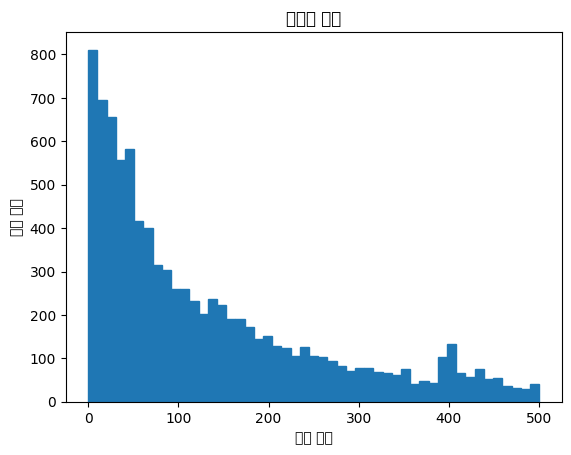

In [29]:
# 모델의 문맥 크기로 자르기 전 텍스트의 단어 개수 분포를 확인한다.
import matplotlib.pyplot as plt
import numpy as np

# 나눔고딕 폰트 적용
plt.rc('font', family='NanumGothic')
# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False


(df_issues["text"].str.split().apply(len).hist(bins=np.linspace(0, 500, 50), grid=False, edgecolor='C0'))
plt.title("이슈당 단어")
plt.xlabel("이슈 개수")
plt.ylabel("단어 개수")
plt.show()

3. 코드를 함께 포스팅하는 경우 보통 이슈의 길이가 커진다.
    - 대부분의 트랜스포머 모델의 문캑의 크기는 512개의 토큰이나 그 이상이기 때문에 일부 긴 이슈르 잘라내도 무방한다.

### Chapter 1-3 훈련 세트 만들기     <a class="anchor" id="chapter1-3"></a>
1. 다중 레이블 문제에서는 훈련 세트와 검증 세트를 만드는 것이 조금 까다롭다.
    - 모든 레이블에 대해 균형잡힌 비율을 보장하지 못하기 때문이다.
    - scikit-multilearn 라이브러리를 사용하면 도움이 된다.

In [30]:
# MultiLableBinarizer를 사용해 pytorch와 tokenization 같은 레이블 모델을 처리가은한 형식으로 변환한다.
#   - 레이블 이름의 리스트를 받고 레이블에 해당하는 위치는 1, 나머지는 0인 벡터를 반환한다.
from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer()
mlb.fit([all_labels])
mlb.transform([["tokenization", "new model"], ["pytorch"]])

array([[0, 0, 0, 1, 0, 0, 0, 1, 0],
       [0, 0, 0, 0, 0, 1, 0, 0, 0]])

In [32]:
print(mlb.classes_)

['documentation' 'examples' 'model training' 'new model' 'pipeline'
 'pytorch' 'tensorflow or tf' 'tokenization' 'usage']


2. 첫 번째 행은 2 개의 1을 포함하는데, 각각 new model과 tokenization 레이블에 해당한다.
    - 두 번째 행은 1 개의 1을 포함하는데, pytorch 레이블에 해당한다.

In [34]:
# scikit-multilearn의 iterative_train_test_split 메서드를 사용해 다중 레이블 훈련 세트와 검증 세트를 만든다.
#   - 레이블의 균형을 잡기 위해 반복적으로 훈련/테스트 세트를 만든다.
from skmultilearn.model_selection import iterative_train_test_split

def balanced_split(df, test_size=0.5):
    ind = np.expand_dims(np.arange(len(df)), axis=1)
    labels = mlb.transform(df["labels"])
    ind_train, _, ind_test, _ = iterative_train_test_split(ind, labels, test_size=test_size)
    return df.iloc[ind_train[:,0]], df.iloc[ind_test[:,0]]

In [36]:
# 데이터를 지도 학습 데이터셋과 비지도 학습 데이터셋으로 나눈다.
#   - balanced_split 함수를 사용해 레이블의 균형을 맞춘다.
from sklearn.model_selection import train_test_split

df_clean = df_issues[["text", "labels", "split"]].reset_index(drop=True).copy()
df_unsup = df_clean.loc[df_clean["split"] == "unlabeled", ["text", "labels"]]
df_sup = df_clean.loc[df_clean["split"] == "labeled", ["text", "labels"]]

np.random.seed(0)
df_train, df_tmp = balanced_split(df_sup, test_size=0.5)
df_valid, df_test = balanced_split(df_tmp, test_size=0.5)

In [37]:
# 쉽게 데이터셋을 토큰화하고 Trainer와 통합하기 위해 모든 분할을 담은 딕셔너리를 만든다.
from datasets import Dataset, DatasetDict

ds = DatasetDict({
    "train": Dataset.from_pandas(df_train.reset_index(drop=True)),
    "valid": Dataset.from_pandas(df_valid.reset_index(drop=True)),
    "test": Dataset.from_pandas(df_test.reset_index(drop=True)),
    "unsup": Dataset.from_pandas(df_unsup.reset_index(drop=True))
})

### Chapter 1-4 훈련 슬라이스 만들기     <a class="anchor" id="chapter1-4"></a>
1. 희소하게 레이블링된 데이터와 다중 레이블 분류에 대해 알아본다.

2. 적은 양의 레이블링된 데이터에서 얼마나 좋은 성능을 내는지 확인하기 위해 훈련 데이터의 슬라이스를 만든다.

In [39]:
# iterate_train_test_split 함수를 사용해 레이블마다 여덟 개 샘플로 시작해서 저체 후련 세트들 담은 슬라이스까지 만든다.
np.random.seed(0)
all_indices = np.expand_dims(list(range(len(ds["train"]))), axis=1)
indices_pool = all_indices
labels = mlb.transform(ds["train"]["labels"])
train_samples = [8, 16, 32, 64, 128]
train_slices, last_k = [], 0

for i, k in enumerate(train_samples):
    # 다음 슬라이스 크기를 채우는데 필요한 샘플을 분할합니다
    indices_pool, labels, new_slice, _ = iterative_train_test_split(
        indices_pool, labels, (k-last_k)/len(labels))
    last_k = k
    if i==0: train_slices.append(new_slice)
    else: train_slices.append(np.concatenate((train_slices[-1], new_slice)))

# 마지막 슬라이스를 포함하면 코랩의 경우 메모리 부족이 발생합니다.
# 대신 코랩 프로(https://colab.research.google.com/signup)를 사용하세요.
# 코랩을 사용하려면 다음 라인을 주석 처리하세요.
train_slices.append(all_indices), train_samples.append(len(ds["train"]))

train_slices = [np.squeeze(train_slice) for train_slice in train_slices]

In [ ]:
print("목표 분할 크기:", train_samples)
print("실제 분할 크기:", [len(x) for x in train_slices])